#                         Data  Cleaning 

###  Step 1: Import Pandas Library and Check Data 

In [124]:
import pandas as pd  
df=pd.read_csv("C:/data_science/Projects/Manufacturing_KPI_Analysis/data/raw/manufacturing_data.csv")

In [125]:
df.head()

,Date,Machine_ID,Shift,Plant_Location,Planned_Production_Time,Downtime,Ideal_Cycle_Time,Downtime_Reason,Operating_Time,Total_Production,Defective_Production,Good_Production
0,2024-04-12,M3,B,Chennai,478,44.0,1.457660,Power Failure,434.0,252,8.0,244
1,2024-12-14,M1,C,Pune,447,98.0,0.944065,Maintenance,349.0,301,11.0,290
2,2024-09-27,M4,A,Pune,465,23.0,0.938673,Power Failure,442.0,425,10.0,415
3,2024-04-16,M3,B,Mumbai,425,61.0,1.205362,Setup,364.0,249,11.0,238
4,2024-03-12,M1,C,Pune,466,90.0,0.980505,Maintenance,376.0,324,11.0,313


In [126]:
df.shape

(5000, 12)

In [127]:
df.columns

Index(['Date', 'Machine_ID', 'Shift', 'Plant_Location',
       'Planned_Production_Time', 'Downtime', 'Ideal_Cycle_Time',
       'Downtime_Reason', 'Operating_Time', 'Total_Production',
       'Defective_Production', 'Good_Production'],
      dtype='object')

In [128]:
df.info() (# Cheking missing Values)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     5000 non-null   object 
 1   Machine_ID               5000 non-null   object 
 2   Shift                    5000 non-null   object 
 3   Plant_Location           5000 non-null   object 
 4   Planned_Production_Time  5000 non-null   int64  
 5   Downtime                 4900 non-null   float64
 6   Ideal_Cycle_Time         4900 non-null   float64
 7   Downtime_Reason          5000 non-null   object 
 8   Operating_Time           5000 non-null   float64
 9   Total_Production         5000 non-null   int64  
 10  Defective_Production     4900 non-null   float64
 11  Good_Production          5000 non-null   int64  
dtypes: float64(4), int64(3), object(5)
memory usage: 468.9+ KB


### Step 2 : Dealing with Missing Values

In [129]:

df.isnull().sum()

Date                         0
Machine_ID                   0
Shift                        0
Plant_Location               0
Planned_Production_Time      0
Downtime                   100
Ideal_Cycle_Time           100
Downtime_Reason              0
Operating_Time               0
Total_Production             0
Defective_Production       100
Good_Production              0
dtype: int64

In [130]:
(df.isnull().sum()/len(df))*100

Date                       0.0
Machine_ID                 0.0
Shift                      0.0
Plant_Location             0.0
Planned_Production_Time    0.0
Downtime                   2.0
Ideal_Cycle_Time           2.0
Downtime_Reason            0.0
Operating_Time             0.0
Total_Production           0.0
Defective_Production       2.0
Good_Production            0.0
dtype: float64

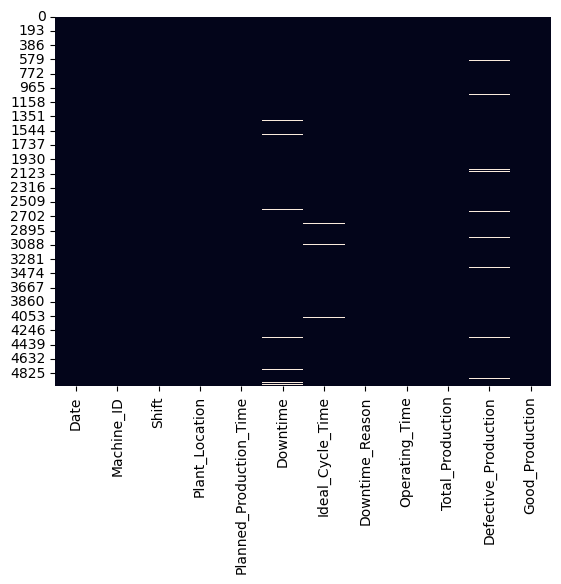

In [131]:
import seaborn as sns
import matplotlib.pyplot as plt 
sns.heatmap(df.isnull(),cbar=False)
plt.show()

In [132]:
# Missing values were randomly distributed across operational columns, indicating no systematic data collection issue.
# Hence, imputation was applied instead of dropping records 

In [133]:
df.isnull().sum()

Date                         0
Machine_ID                   0
Shift                        0
Plant_Location               0
Planned_Production_Time      0
Downtime                   100
Ideal_Cycle_Time           100
Downtime_Reason              0
Operating_Time               0
Total_Production             0
Defective_Production       100
Good_Production              0
dtype: int64

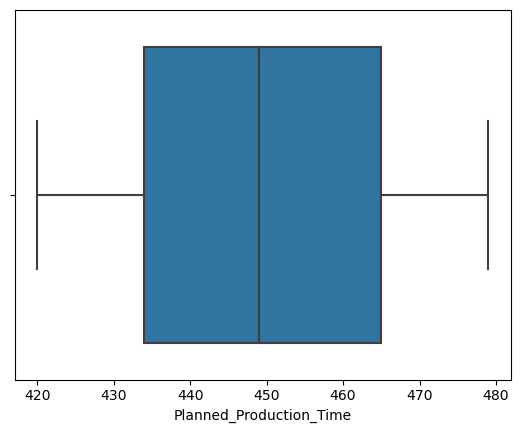

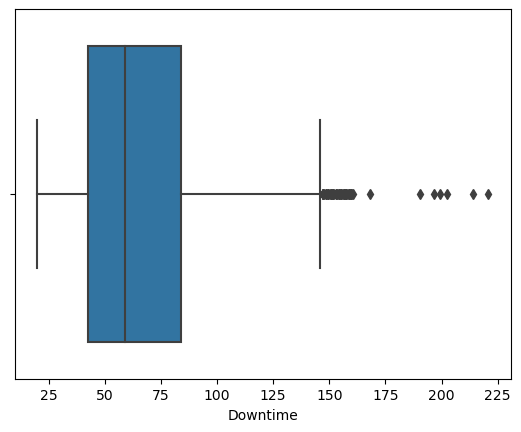

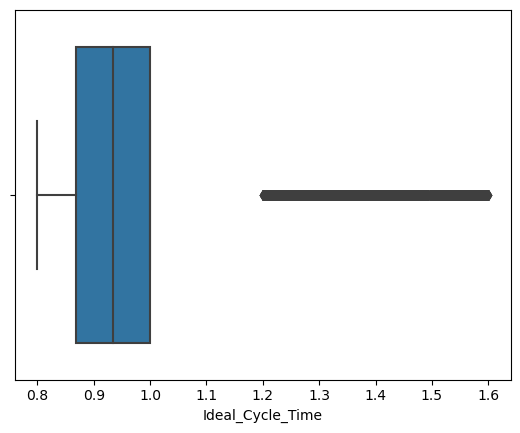

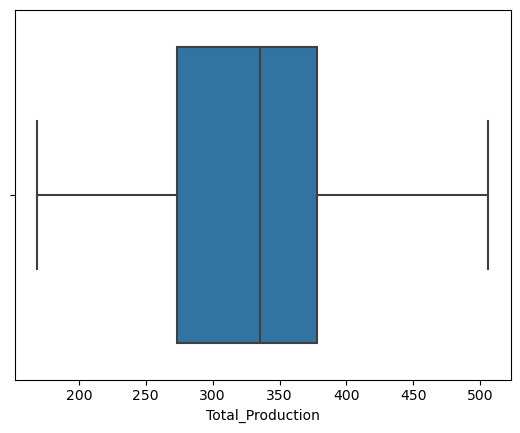

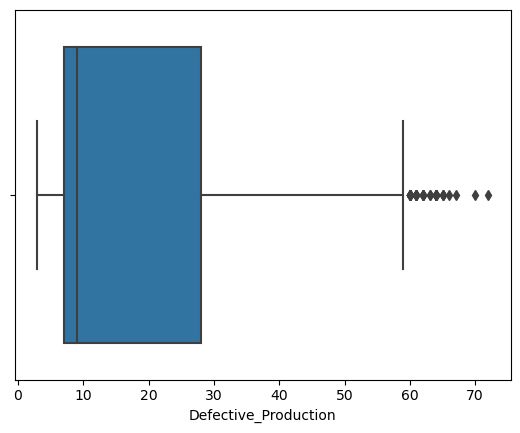

In [134]:
import matplotlib.pyplot as plt 
import seaborn as sns 
numeric_cols=["Planned_Production_Time","Downtime","Ideal_Cycle_Time","Total_Production","Defective_Production"]
for col in numeric_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.show()

In [135]:
df["Downtime"]=df["Downtime"].fillna(df["Downtime"].median())
df["Ideal_Cycle_Time"]=df["Ideal_Cycle_Time"].fillna(df["Ideal_Cycle_Time"].median())
df["Defective_Production"]=df["Defective_Production"].fillna(0) # Special Domain Case


In [136]:

numeric_cols=["Planned_Production_Time","Downtime","Ideal_Cycle_Time","Total_Production","Defective_Production"]
for col in numeric_cols:
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1
    lower=Q1-1.5 * IQR 
    upper= Q3 + 1.5 * IQR 
    df[col]=df[col].clip(lower,upper)

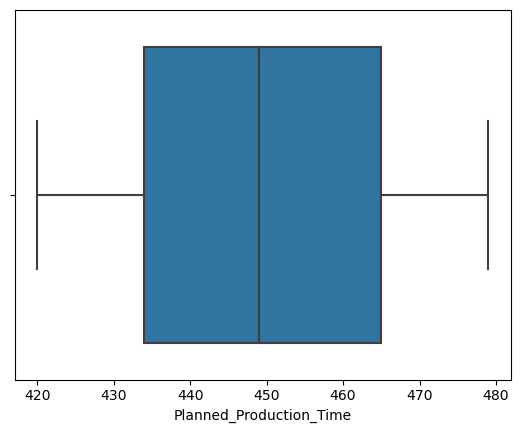

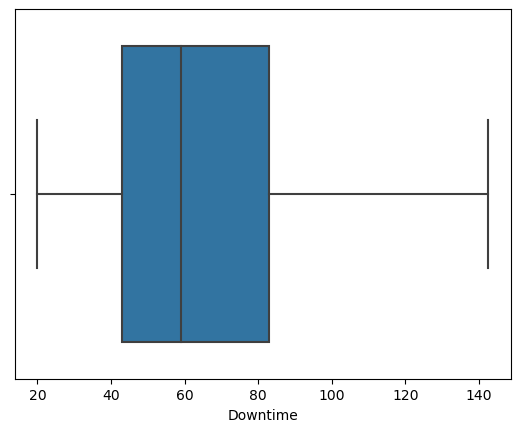

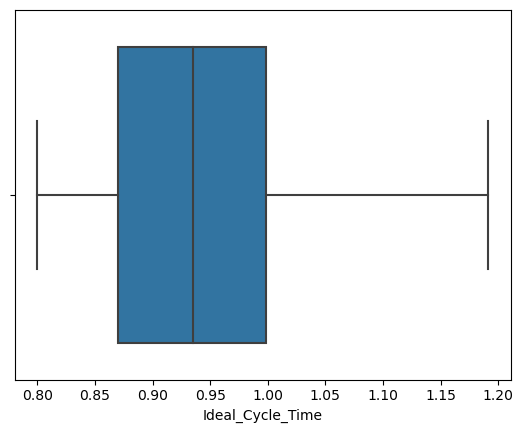

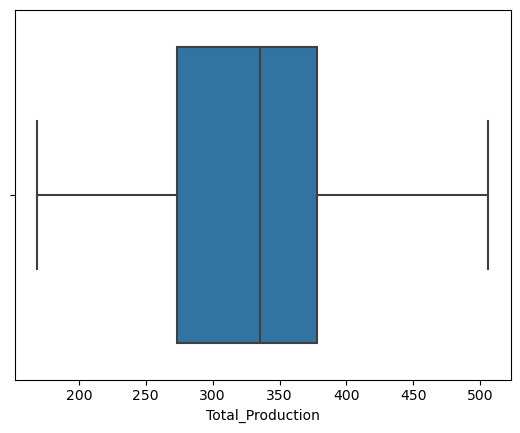

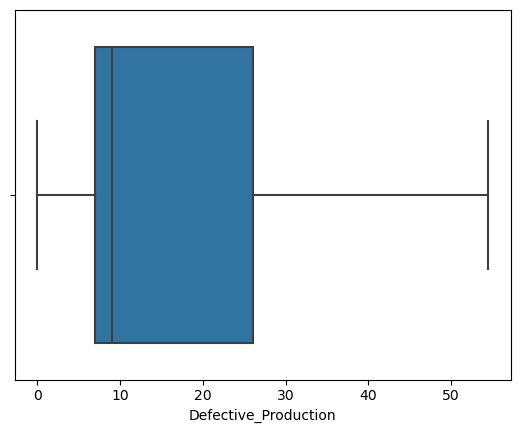

In [137]:
import matplotlib.pyplot as plt 
import seaborn as sns 
numeric_cols=["Planned_Production_Time","Downtime","Ideal_Cycle_Time","Total_Production","Defective_Production"]
for col in numeric_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.show()
    

In [138]:
# Imputing Missing values of Operating_Time , Good_Production from the datasets as these columns are derived 


In [139]:
df["Operating_Time"]=df["Planned_Production_Time"]-df["Downtime"]
df["Good_Production"]=df["Total_Production"]-df["Defective_Production"]

In [141]:
# Safety Check no reasonable
df[["Operating_Time","Good_Production"]].describe()

,Operating_Time,Good_Production
count,5000.00000,5000.000000
mean,382.53734,311.344600
std,35.45007,63.570871
min,277.50000,161.000000
25%,361.00000,263.000000
50%,388.00000,314.000000
75%,409.00000,357.000000
max,458.00000,495.000000


In [142]:
df[["Downtime","Ideal_Cycle_Time","Total_Production","Defective_Production"]].skew()

Downtime                0.817916
Ideal_Cycle_Time        0.727811
Total_Production       -0.121817
Defective_Production    1.284964
dtype: float64

In [143]:
# Calculating KPI'S 
# Availability 
# Out of total planned time, how much time machine was actually running
df["Availability"]=df["Operating_Time"]/df["Planned_Production_Time"]

In [144]:
df["Availability"].describe()

count    5000.000000
mean        0.851193
std         0.069214
min         0.660714
25%         0.814978
50%         0.868304
75%         0.904810
max         0.958159
Name: Availability, dtype: float64

In [145]:
df[(df["Availability"] > 1) | (df["Availability"] < 0)]

,Date,Machine_ID,Shift,Plant_Location,Planned_Production_Time,Downtime,Ideal_Cycle_Time,Downtime_Reason,Operating_Time,Total_Production,Defective_Production,Good_Production,Availability


In [146]:
# Performance
# How fast the machine is running compared to its ideal speed
df["Performance"] = (df["Ideal_Cycle_Time"] * df["Total_Production"]) / df["Operating_Time"]

In [147]:
df["Performance"].describe()

count    5000.000000
mean        0.815283
std         0.081738
min         0.482608
25%         0.771589
50%         0.825650
75%         0.872005
max         1.121682
Name: Performance, dtype: float64

In [148]:
df[df["Performance"] < 0]

,Date,Machine_ID,Shift,Plant_Location,Planned_Production_Time,Downtime,Ideal_Cycle_Time,Downtime_Reason,Operating_Time,Total_Production,Defective_Production,Good_Production,Availability,Performance


In [149]:
# Quality 
# “Out of total production, how much is defect-free”
df["Quality"] = df["Good_Production"] / df["Total_Production"]

In [150]:
df["Quality"].describe()

count    5000.000000
mean        0.951846
std         0.040021
min         0.851429
25%         0.920979
50%         0.969784
75%         0.978082
max         1.000000
Name: Quality, dtype: float64

In [151]:
df[(df["Quality"] > 1) | (df["Quality"] < 0)]

,Date,Machine_ID,Shift,Plant_Location,Planned_Production_Time,Downtime,Ideal_Cycle_Time,Downtime_Reason,Operating_Time,Total_Production,Defective_Production,Good_Production,Availability,Performance,Quality


In [152]:
# OEE (Overall Equipment Effectiveness)
# Overall efficiency of a machine considering time, speed, and quality
df["OEE"] = df["Availability"] * df["Performance"] * df["Quality"]

In [153]:
df["OEE"].describe()

count    5000.000000
mean        0.659331
std         0.082937
min         0.383535
25%         0.598494
50%         0.653337
75%         0.716221
max         0.980870
Name: OEE, dtype: float64

In [154]:
df[(df["OEE"] > 1) | (df["OEE"] < 0)]

,Date,Machine_ID,Shift,Plant_Location,Planned_Production_Time,Downtime,Ideal_Cycle_Time,Downtime_Reason,Operating_Time,Total_Production,Defective_Production,Good_Production,Availability,Performance,Quality,OEE


In [155]:
# Analysis and Insights

In [156]:
# Overall KPI Summary

In [157]:
df[["Availability", "Performance", "Quality", "OEE"]].mean()

Availability    0.851193
Performance     0.815283
Quality         0.951846
OEE             0.659331
dtype: float64

In [158]:
df["Performance"] = df["Performance"].clip(upper=1)
df["Quality"] = df["Quality"].clip(upper=1)
df["OEE"] = df["Availability"] * df["Performance"] * df["Quality"]

In [159]:
df[(df["OEE"] > 1) | (df["OEE"] < 0)]

,Date,Machine_ID,Shift,Plant_Location,Planned_Production_Time,Downtime,Ideal_Cycle_Time,Downtime_Reason,Operating_Time,Total_Production,Defective_Production,Good_Production,Availability,Performance,Quality,OEE


In [160]:
df[["Availability", "Performance", "Quality", "OEE"]].mean()

Availability    0.851193
Performance     0.815204
Quality         0.951846
OEE             0.659268
dtype: float64

In [118]:
# Analysis and Insights

In [162]:
# Machine-wise Analysis
machine_kpi = df.groupby("Machine_ID")[["Availability", "Performance", "Quality", "OEE"]].mean()

machine_kpi


,Availability,Performance,Quality,OEE
Machine_ID,,,,
M1,0.751729,0.838275,0.972085,0.612104
M2,0.873470,0.849204,0.889061,0.659539
M3,0.870671,0.723982,0.967335,0.609717
M4,0.908238,0.848732,0.981712,0.756728


In [166]:
best_machine = machine_kpi["OEE"].idxmax()
worst_machine = machine_kpi["OEE"].idxmin()

print(f"Best Machine: {best_machine}")
print(f"Worst Machine: {worst_machine}")

Best Machine: M4
Worst Machine: M3


In [163]:
# Root Cause Analysis
df.groupby("Machine_ID")[["Availability", "Performance", "Quality"]].mean()

,Availability,Performance,Quality
Machine_ID,,,
M1,0.751729,0.838275,0.972085
M2,0.873470,0.849204,0.889061
M3,0.870671,0.723982,0.967335
M4,0.908238,0.848732,0.981712


In [164]:
# Downtime Reason Analysis
df.groupby("Downtime_Reason")["Downtime"].mean().sort_values(ascending=False)

Downtime_Reason
Breakdown        73.065449
Power Failure    65.547695
Setup            64.671924
Maintenance      64.060236
Name: Downtime, dtype: float64

In [168]:
# Shift Wist Performance
shift_kpi=df.groupby("Shift")["OEE"].mean().sort_values()
shift_kpi

Shift
C    0.620315
B    0.658880
A    0.697204
Name: OEE, dtype: float64

In [169]:
best_shift = shift_kpi.idxmax()
worst_shift = shift_kpi.idxmin()

print(f"Best Shift: {best_shift}")
print(f"Worst Shift: {worst_shift}")

Best Shift: A
Worst Shift: C


In [170]:
df.to_csv("../data/processed/final_manufacturing_data.csv", index=False)

print("\n Analysis Completed & Data Saved")


 Analysis Completed & Data Saved
